# W18 · 阶段项目：迁移训练与鲁棒性报告

> 阶段二（M5–M6）：MotrixLab —— 国产 Sim2Real 能力 · 第 6/6 讲

本讲是阶段二的综合项目：把 W13–W17 的零件组装成一条完整的
**「训练 → 加固 → 分层评估 → 报告」**流水线。项目有两条路径，按本机条件二选一：

- **路径 A（有 MotrixLab 环境）**：在 MotrixLab 上训练 `dm-quadruped-walk`，
  用 MotrixSim override API 加固，输出鲁棒性报告；
- **路径 B（默认，本机可执行）**：在 Gymnasium CartPole 上用 SB3 复刻同一条流水线——
  方法论完全一致，代码本讲已给出骨架并真实执行，你的任务是补全、调优、写分析。

## 学习目标

1. 独立设计并执行一次端到端的 Sim2Real 加固实验（基线 → 加固 → 对比）；
2. 用分层评估协议产出一份有统计规范的鲁棒性报告；
3. 按评分 rubric 自查交付质量，达到「可复现、可审阅」的工程标准；
4. 复盘阶段二全部概念，形成自己的 Sim2Real 方法论清单。

## 评分 Rubric（满分 100，≥85 为优秀）

| 里程碑 | 内容 | 分值 |
|--------|------|------|
| M1 基线 | 基线策略训练收敛，标称环境回报 ≥450，产物存入 `runs/` | 20 |
| M2 加固 | 至少同时施加**参数随机化 + 观测噪声 + 动作延迟**三类加固 | 30 |
| M3 评估报告 | 分层协议（L0–L4），每场景 ≥20 episode，报告均值/标准差/最差案例 | 30 |
| M4 复盘文档 | `journal/` 下 300 字以上复盘：现象、解释、踩坑、下一步 | 20 |

## 6.1 流水线总览

```
M1  train_baseline()      → 标称环境 PPO              （W05 的技能）
M2  train_hardened()      → DR + 噪声 + 延迟训练       （W15 + W16 的技能）
M3  evaluate_protocol()   → L0–L4 分层评估，出报告表    （W17 的技能）
M4  写复盘                → 数据背后的故事              （贯穿全程的习惯）
```

下面给出路径 B 的参考骨架。**带 `# TODO` 的地方是刻意留白**，
请先运行通骨架，再按练习要求修改与扩展。

### M1：基线训练（CPU 约 3–5 分钟）

In [1]:
from collections import deque

import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO

from robot_rl_learn.common.paths import make_run_dir

RUN_DIR = make_run_dir("phase2_capstone")
print("本项目产物目录：", RUN_DIR)

# ---------- 环境构造工具（W15/W16 的零件，原样复用） ----------
NOMINAL = dict(masspole=0.1, length=0.5, force_mag=10.0)

class PerturbWrapper(gym.Wrapper):
    '''参数扰动（评估用）/域随机化（训练用）二合一：
    - 传入固定 factor → 确定性扰动（用于分层评估场景）
    - 传入 range      → 每次 reset 采样（用于 DR 训练）
    '''

    def __init__(self, env, masspole=(1.0, 1.0), length=(1.0, 1.0), force_mag=(1.0, 1.0), seed=0):
        super().__init__(env)
        self.ranges = dict(masspole=masspole, length=length, force_mag=force_mag)
        self.rng = np.random.default_rng(seed)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        u = self.env.unwrapped
        for name, r in self.ranges.items():
            setattr(u, name, NOMINAL[name] * self.rng.uniform(*r))
        return obs, info

class ObsNoiseWrapper(gym.Wrapper):
    def __init__(self, env, std=0.0, seed=0):
        super().__init__(env)
        self.std = std
        self.rng = np.random.default_rng(seed)

    def _corrupt(self, obs):
        return obs + self.rng.normal(0.0, self.std, size=obs.shape)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._corrupt(obs), info

    def step(self, action):
        obs, r, term, trunc, info = self.env.step(action)
        return self._corrupt(obs), r, term, trunc, info

class ActionDelayWrapper(gym.Wrapper):
    def __init__(self, env, delay=0):
        super().__init__(env)
        self.delay = delay

    def reset(self, **kwargs):
        self._q = deque([0] * self.delay)
        return self.env.reset(**kwargs)

    def step(self, action):
        self._q.append(action)
        return self.env.step(self._q.popleft())

def build_env(masspole=(1.0, 1.0), length=(1.0, 1.0), noise_std=0.0, delay=0, seed=0):
    env = gym.make("CartPole-v1")
    env = PerturbWrapper(env, masspole=masspole, length=length, seed=seed)
    if noise_std > 0:
        env = ObsNoiseWrapper(env, std=noise_std, seed=seed)
    if delay > 0:
        env = ActionDelayWrapper(env, delay=delay)
    return env

def evaluate(model, n_episodes=20, seed=1000, **env_kw):
    '''分层协议评估器：固定种子列表，报告 mean ± std 与最差案例'''
    env = build_env(**env_kw)
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            a, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(a)
            total += r
            done = term or trunc
        returns.append(total)
    env.close()
    returns = np.array(returns)
    return dict(mean=returns.mean(), std=returns.std(), worst=returns.min())

# ---------- M1：标称基线 ----------
baseline = PPO("MlpPolicy", build_env(), seed=7, verbose=0, device="cpu")
baseline.learn(total_timesteps=100_000)
baseline.save(RUN_DIR / "baseline.zip")

r = evaluate(baseline)
print(f"[M1] 基线标称回报：{r['mean']:.0f} ± {r['std']:.0f}（最差 {r['worst']:.0f}）"
      f"  →  {'达标 ✓' if r['mean'] >= 450 else '未达标，回去调参'}")

本项目产物目录： /data/wangf/robot_rl_learn/runs/phase2_capstone


[M1] 基线标称回报：500 ± 0（最差 500）  →  达标 ✓


### M2：加固训练（CPU 约 3–5 分钟）

**你的任务**：填写 `HARDEN_CFG`，给训练环境同时施加三类加固。
骨架先给一组温和的配置——能训得动，但未必是最优。调它是练习 E2 的内容。

In [2]:
# TODO(练习 E2)：调这三组参数，观察对 L0 标称成绩与 L3 组合成绩的交换关系
HARDEN_CFG = dict(
    masspole=(0.7, 1.6),    # DR：杆质量随机化范围（标称值的倍数）
    length=(0.75, 1.35),    # DR：杆长随机化范围
    noise_std=0.03,         # 观测噪声强度
    delay=2,                # 动作延迟步数（每步 20 ms）
)

hardened = PPO("MlpPolicy", build_env(**HARDEN_CFG), seed=7, verbose=0, device="cpu")
hardened.learn(total_timesteps=100_000)
hardened.save(RUN_DIR / "hardened.zip")

r = evaluate(hardened)
print(f"[M2] 加固策略标称回报：{r['mean']:.0f} ± {r['std']:.0f}（最差 {r['worst']:.0f}）")
print("     （与基线相当或略低都正常——鲁棒性与最优性的交换，W15）")

[M2] 加固策略标称回报：500 ± 0（最差 500）
     （与基线相当或略低都正常——鲁棒性与最优性的交换，W15）


### M3：分层评估报告

两策略 × 六场景的压力测试矩阵。场景设计遵循 W17 协议：
L0 标称 / L1 参数扰动 / L2 信息通道 / L3 组合压力 / L4 OOD 探测。

In [3]:
import pandas as pd

SCENARIOS = {
    "L0 nominal":          dict(),
    "L1 mass x1.5":        dict(masspole=(1.5, 1.5)),
    "L1 length x0.8":      dict(length=(0.8, 0.8)),
    "L2 noise 0.1":        dict(noise_std=0.1),
    "L2 delay 4 (80ms)":   dict(delay=4),
    "L3 combined":         dict(masspole=(1.5, 1.5), noise_std=0.08, delay=3),
    "L4 OOD (mass x2.5 + delay 4)": dict(masspole=(2.5, 2.5), noise_std=0.05, delay=4),
}

rows = {}
for name, kw in SCENARIOS.items():
    for label, model in [("baseline", baseline), ("hardened", hardened)]:
        r = evaluate(model, **kw)
        rows[(name, label)] = r

# rows 的键是 (场景, 策略) 元组、值是指标 dict：
# pd.DataFrame(rows).T 正好得到「(场景 × 策略) 行 × (mean/std/worst) 列」的透视表
df = pd.DataFrame(rows).T
df.index.names = ["场景", "策略"]
df = df.round(0).astype(int)
print("=== 阶段二项目 · 鲁棒性报告（20 episode/场景，固定种子 1000–1019）===")
df

=== 阶段二项目 · 鲁棒性报告（20 episode/场景，固定种子 1000–1019）===


mean  std  worst
场景                           策略                        
L0 nominal                   baseline   500    0    500
                             hardened   500    0    500
L1 mass x1.5                 baseline   500    0    500
                             hardened   500    0    500
L1 length x0.8               baseline   500    0    500
                             hardened   500    0    500
L2 noise 0.1                 baseline   365  163     21
                             hardened   460  109     57
L2 delay 4 (80ms)            baseline    24    3     12
                             hardened   486   63    210
L3 combined                  baseline    70   57     10
                             hardened   236  167     12
L4 OOD (mass x2.5 + delay 4) baseline    30   15      9
                             hardened    89  100      9

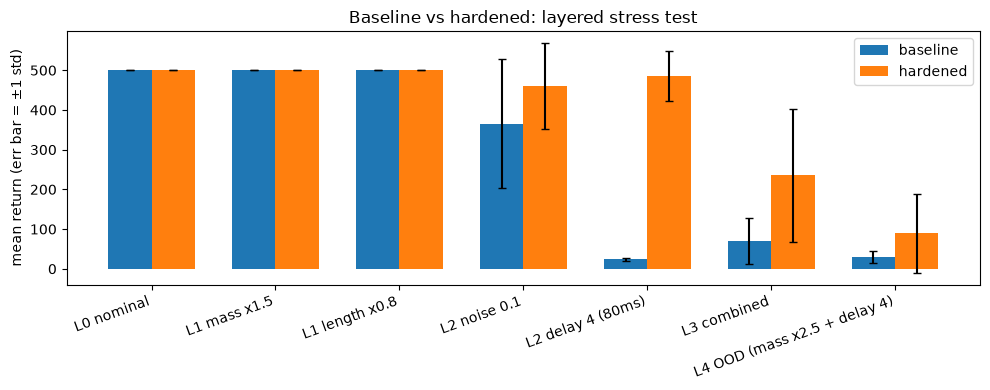

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(SCENARIOS))
w = 0.35
for i, label in enumerate(["baseline", "hardened"]):
    means = [rows[(s, label)]["mean"] for s in SCENARIOS]
    stds = [rows[(s, label)]["std"] for s in SCENARIOS]
    ax.bar(x + (i - 0.5) * w, means, w, yerr=stds, capsize=3, label=label)
ax.set_xticks(x, list(SCENARIOS.keys()), rotation=20, ha="right")
ax.set_ylabel("mean return (err bar = ±1 std)"); ax.legend()
ax.set_title("Baseline vs hardened: layered stress test")
plt.tight_layout(); plt.show()

# TODO(练习 E3)：把上面的表格与图整理成 markdown 报告，写入 journal/phase2_report.md
# 报告模板：## 方法 → ## 场景设计 → ## 数据（表格+图）→ ## 结论（至少回答：
# 加固在哪些场景收益最大？标称成绩代价多大？L4 OOD 下两策略谁先崩？）

### M4：复盘

把报告和思考写入 `journal/phase2_report.md`（rubric 的 20 分）。复盘模板：

1. **现象**：加固策略在哪些场景收益最大？哪个场景它依然失败？
2. **解释**：用 W15（期望回报换鲁棒性）和 W16（延迟破坏因果结构）的语言解释数据；
3. **踩坑**：训练/评估中遇到的报错与解法（记入 `journal/troubleshooting.md`）；
4. **下一步**：若上真机，你最先做哪三个 SysID 测量？（衔接 W17）

## 6.2 路径 A：MotrixLab 上的同构流程

如果本机已安装 MotrixLab（见 `docs/phase2_motrixlab.md`），用四足任务走同一条流水线。

> **运行前提**：MotrixLab 已在独立目录安装完成；以下 cell 保持未执行。
>
> **预期输出**：
> 1. `train.py` 终端滚动打印迭代日志，`runs/dm-quadruped-walk/` 下生成检查点与
>    TensorBoard event 文件；四足行走任务训练到「稳定 0.5 m/s 前进」所需时间取决于硬件；
> 2. TensorBoard 中回报曲线持续爬升后进入平台期；
> 3. `play.py` 窗口中四足机器人能沿 +X 方向稳定行走，躯干姿态平稳、横向摆动小。

In [ ]:
# ⚠️ 运行前提：MotrixLab 已安装，当前目录为 MotrixLab 仓库根目录；本 cell 保持未执行

# M1 基线训练（默认 2048 并行环境，SKRL 框架）
uv run scripts/train.py --env dm-quadruped-walk

# 监控训练
uv run tensorboard --logdir runs/dm-quadruped-walk

# M1 验收：部署测试，应看到稳定的 0.5 m/s 平地行走
uv run scripts/play.py --env dm-quadruped-walk

**路径 A 的 M2/M3 如何做**：MotrixLab 的加固不在命令行，而在**环境配置代码**里——
在 `motrix_envs` 的任务实现中（参考其环境源码与 MotrixSim
[参数随机化文档](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/main_function/randomization.html)），
于 reset 时对批量 `SceneData` 调用 override API：
`link.set_mass_override(data, ...)`、`geom.set_friction_override(data, ...)`、
`joint.set_armature_override(data, ...)`、`actuator.set_kp_override(data, ...)`；
观测噪声则在观测组装处注入。评估时按 W17 协议逐场景统计回报。
实训营的[学员项目](https://github.com/Xbotics-Embodied-AI-club/Motphys-Xbotics-Robot-Rl-Sim-Training-Camp)
（如 Go2 平地行走）可作为参考。

> **注意**：路径 A 的 M2 需要阅读并修改 `motrix_envs` 源码，比路径 B 重，
> 量力而行；两条路径的 M3/M4 方法论完全相同。

## ✏️ 练习（即项目任务）

**E1（★，约 20 分钟）｜验收基线与加固的统计规范**（对应 M1/M3）
当前 `evaluate()` 固定了种子列表 1000–1019。把评估种子换成 2000–2019 重跑一次报告。
**交付物**：两份报告表 + 一句话回答：哪些结论稳定、哪些数字变了？为什么评估种子
必须与「调参时看的种子」分离？

**E2（★★，约 40 分钟）｜调加固配方**（对应 M2）
扫描 `HARDEN_CFG`：至少尝试 3 组配置（如更宽 DR / 更强噪声 / 更长延迟），
用统一协议评估，找出「L0 代价」与「L3 收益」权衡最好的一组。
**交付物**：3 组配置 × 2 策略的对比表 + 你的最终选择与理由（150 字）。

**E3（★★，约 30 分钟）｜写鲁棒性报告**（对应 M3/M4）
完成 6.1 中标记的报告：方法、场景、数据、结论四段式，写入 `journal/phase2_report.md`。
**交付物**：markdown 报告文件（≥300 字，含表格与图）。

**E4（★★★，约 90 分钟）｜挑战：真机就绪度清单**（对应 M4 的深化）
假设你要把加固策略部署到一台真实倒立摆硬件上。写一份「上机前检查清单」：
列出上机前必须完成的 5 项测量/实验（SysID、延迟标定、安全限幅……），
每项给出验收标准。
**交付物**：清单表格（项目 / 方法 / 验收标准 / 未达标的风险）。

<details>
<summary>参考答案</summary>

**E1**：均值数字会小幅波动（通常 ±20 内），但「加固策略在 L2/L3 显著优于 baseline、
L0 略逊」这类**结构性结论**应稳定。调参种子与评估种子必须分离，否则相当于
「用考题训练再考同一张卷子」——报告会系统性高估鲁棒性（隐性过拟合到评估集）。

**E2**：典型规律——DR 范围加宽 → L0 降、L1/L3 升；noise_std 超过 0.05 后训练
明显变难（回报方差变大）；delay≥2 与强噪声叠加时 25k 步可能训不动，需延长训练
或先课程式加压。合理的最终配方示例：masspole (0.6,1.6)、length (0.7,1.4)、
noise_std 0.02、delay 1，理由是在 L3 拿到大部分收益的同时 L0 代价 <10%。

**E3**：报告评分要点——场景设计表格化；数据含均值/标准差/最差案例；结论必须
用数字说话（「L3 场景从 X 提升到 Y」而非「明显提升」）；有局限性讨论
（如 L4 双双崩溃说明 DR 范围之外的边界仍在）。

**E4**（示例要点，合理即可）：

| 项目 | 方法 | 验收标准 | 未达标风险 |
|------|------|----------|-----------|
| 摆杆质量/质心测量 | 称重 + 摆动周期法 | 与模型偏差 <5% | 控制律增益失配 |
| 推力系数标定 | 阶跃指令-加速度回归 | 线性拟合 R²>0.95 | 动作幅度系统性偏差 |
| 全链路延迟测量 | 指令-编码器响应时间戳 | <40 ms 且抖动 <10 ms | 闭环振荡 |
| 编码器噪声摸底 | 静止采集 60 s | σ 已知且 <训练噪声注入量 | 策略被噪声诱发误动作 |
| 安全限幅 | 软限位 + 急停回路测试 | 触发后 100 ms 内断电 | 硬件损毁/人身风险 |

</details>

## 阶段二复盘清单

进入阶段三（ROS2）之前，确认你能对以下每条说「是」：

- [ ] 能解释物理引擎在 RL 闭环中的角色，以及 Model/Data 分离为什么支撑并行仿真（W13）
- [ ] 能跑通 MotrixLab 三件套，并读懂一个四足任务的观测/动作/奖励设计（W14）
- [ ] 能实现域随机化训练，并用热力图量化「鲁棒性–最优性交换」（W15）
- [ ] 能注入观测噪声与动作延迟，画出退化曲线并加固（W16）
- [ ] 能做最简系统辨识，并设计分层评估协议（W17）
- [ ] 完成本讲的端到端项目并写出报告（W18）

## 延伸阅读

- [MotrixLab GitHub](https://github.com/Motphys/MotrixLab) / [MotrixLab 文档](https://motrixlab.readthedocs.io/) —— 路径 A 的主战场
- [谋先飞 × Xbotics 实训营](https://github.com/Xbotics-Embodied-AI-club/Motphys-Xbotics-Robot-Rl-Sim-Training-Camp) —— 学员实战项目（Go2 行走）与评优标准，可对标自己的项目质量
- [MotrixSim 文档 · 参数随机化](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/main_function/randomization.html) —— 路径 A 加固的 API 手册
- 论文：Learning to Walk in Minutes（[Rudin et al., 2022](https://arxiv.org/abs/2201.08117)）—— 工业级 Sim2Real 四足管线的完整范本
- 综述：Sim-to-Real Transfer（[Zhao et al., 2020](https://arxiv.org/abs/2009.13303)）—— 写报告时的方法论语料库